# CBP-Vet: the data engine, end to end

**What this notebook is.** The spine of the work: run it top to bottom and you will have
done, in miniature, what the build did at full scale. Every cell loads a real artifact
produced by the real pipeline. Nothing here is illustrative or mocked.

**What it deliberately is not.** Exhaustive. Where a step has depth worth a page of
explanation, a bug worth a post-mortem, or a decision worth an audit trail, this notebook
states the point and sends you to the full write-up:

- **`Build-Tutorial_Data-Engine.md`** — Chapters 0 to 8, one per build, plus **Appendix A**,
  a complete error register (14 errors resolved with cause and evidence, 6 open with reasons).
- **`PROJECT-LEDGER.md`** — the dated history.
- **`STATE_2026-08-04.md`** — where everything stands right now.

Cross-references appear inline as **[Tutorial: Chapter N]**.

---

## The problem, in one paragraph

mono-cbp searches eclipsing-binary light curves for circumbinary planets. Its search over
512 binaries produced **7,176 candidate events**, narrowed by model comparison to **1,647
that a human had to inspect by eye**, which yielded **1** real candidate. Those 1,647 break
down into 1,084 unmasked stellar eclipses, 258 detrending artefacts, 135 systematics and
138 nearby-binary contaminations.

That queue is the bottleneck. We are building the first machine-learning **vetter** to rank
it, so a human looks at 100 plots instead of 1,647 and still finds the planet.

To train one you need labelled examples of both classes. Nobody has them: there are about
**fourteen** known transiting circumbinary planets in the world. Fourteen is not a training
set, it is a **test** set, and we treat it as exactly that, sealed until the end.

So we manufacture the training data. That is the data engine. **[Tutorial: Chapter 0]**

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import h5py

REPO = os.path.expanduser('~/cbp-vet')
os.chdir(REPO)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False})

def have(p): return os.path.exists(os.path.join(REPO, p))
print('repo:', REPO)

repo: /Users/wilsonwu/cbp-vet


---
## 1. The negatives are free

Run mono-cbp's own search over our frozen 1,946 light curves. Every event it flags is,
almost certainly, a false positive: these are ordinary eclipsing binaries and real
circumbinary planets are vanishingly rare. Thousands of genuine, in-the-wild false
positives, produced by exactly the pipeline our vetter sits downstream of.

Three landmines had to be cleared first, each of which fails **silently**. The worst: the
cached files carry a five-name header over **four** data columns, so there is no eclipse
mask, and searching them as-is runs with **no masking at all**. **[Tutorial: Chapter 1]**

In [2]:
ev = pd.read_csv('data/search_frozen/out/detected_events.txt', sep=r'\s+')
ev.columns = [c.lower() for c in ev.columns]
meta = json.load(open('data/search_frozen/out/run_meta.json'))
n_files = meta['n_files_searched']

print(f"light curves searched : {n_files:,}   (1 of 1,946 excluded: it is empty in the cache)")
print(f"TCEs flagged          : {len(ev):,}")
print(f"systems producing them: {ev.tic.nunique()}")
print()
print('THE REPLICATION CHECK'.center(52, '-'))
print(f"  ours     : {len(ev)/n_files:.3f} TCEs per light curve")
print(f"  mono-cbp : {7176/3808:.3f} TCEs per light curve   (7,176 over 3,808)")
print(f"  agreement: {100*abs(len(ev)/n_files - 7176/3808)/(7176/3808):.1f} % apart")

light curves searched : 1,945   (1 of 1,946 excluded: it is empty in the cache)
TCEs flagged          : 3,672
systems producing them: 518

---------------THE REPLICATION CHECK----------------
  ours     : 1.888 TCEs per light curve
  mono-cbp : 1.884 TCEs per light curve   (7,176 over 3,808)
  agreement: 0.2 % apart


That 0.2 percent agreement, on an independent set of light curves, is the evidence that the
search stage is replicated. It is the single most useful number to show the mentor.

---
## 2. A good feature the incumbent computes and throws away

The finder groups the peaks found across its 21 biweight detrending windows, then stores
only `det_dep = 1 if len(group) <= 18 else 0`. The count itself is discarded.

A real astrophysical dip survives most windows; a detrending artefact survives few. That is
a strong, free vetting feature, reduced to one bit. Because this search never repeats, not
capturing it here would have lost it permanently.

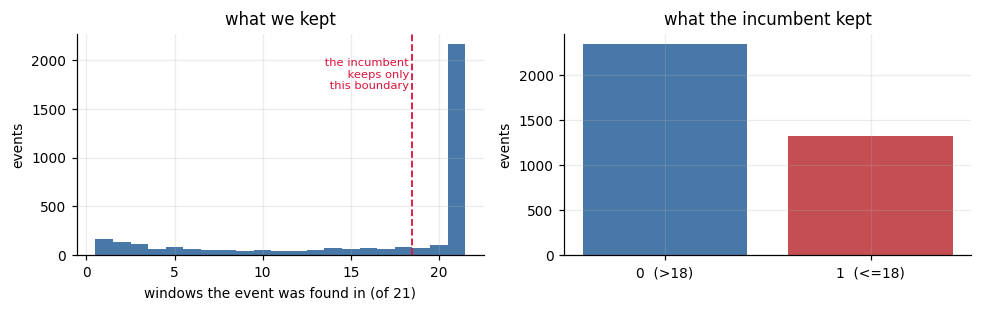

median 21, p25 12, 58.9% at the 21-window ceiling, 15.1% in <=5 windows
consistency check: det_dependence == 1 exactly when n <= 18, on every row  OK


In [3]:
n = ev.n_detrend_detections.astype(int)
fig, ax = plt.subplots(1, 2, figsize=(9, 2.9))
ax[0].hist(n, bins=np.arange(0.5, 22.5), color='#4878a8')
ax[0].axvline(18.5, color='crimson', ls='--', lw=1.2)
ax[0].set(xlabel='windows the event was found in (of 21)', ylabel='events',
          title='what we kept')
ax[0].text(18.3, ax[0].get_ylim()[1]*0.75, ' the incumbent\n keeps only\n this boundary',
           color='crimson', fontsize=7.5, ha='right')
ax[1].bar(['0  (>18)', '1  (<=18)'], ev.det_dependence.value_counts().reindex([0,1]).values,
          color=['#4878a8', '#c44e52'])
ax[1].set(ylabel='events', title='what the incumbent kept')
plt.tight_layout(); plt.show()

print(f"median {int(np.median(n))}, p25 {int(np.percentile(n,25))}, "
      f"{100*(n==21).mean():.1f}% at the 21-window ceiling, {100*(n<=5).mean():.1f}% in <=5 windows")
assert ((ev.det_dependence==1) == (n<=18)).all(), 'flag and count disagree'
print('consistency check: det_dependence == 1 exactly when n <= 18, on every row  OK')

---
## 3. The positives must be injected: the profile bank

mono-cbp ships 49 transit shapes, a 7x7 grid all at impact parameter 0. Train on those and
a classifier can memorise 49 templates without learning what a transit looks like.

Ours is **16,384 profiles from a Sobol sequence**. Sobol is low-discrepancy: random draws in
six dimensions clump and leave holes, while Sobol fills space evenly by construction, so the
same count covers the shape space far better. **[Tutorial: Chapter 2]**

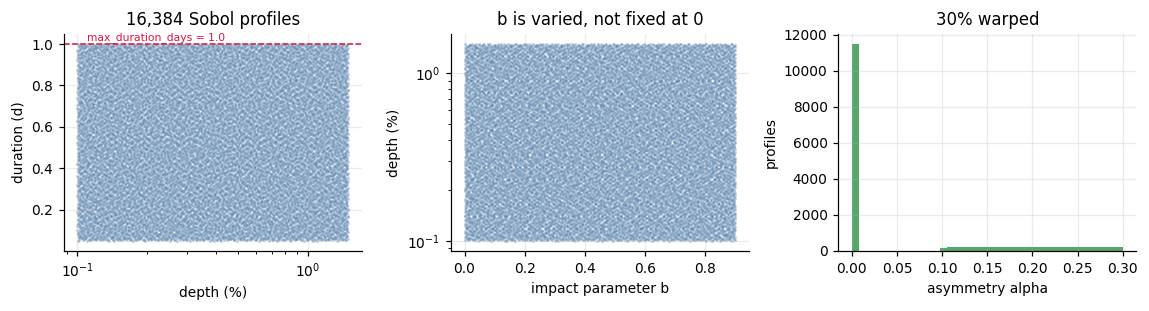

The asymmetry axis exists because a real circumbinary transit is NOT symmetric:
the star being crossed is itself moving. If every injected positive were
perfectly symmetric, "is this symmetric" would give the label away.

warp preserves depth to 9.2e-02? see Tutorial Chapter 2: the warp is exact to 1.7e-14; the residual is an
INHERITED mono-cbp approximation, confined to 11 near-grazing profiles at b > 0.885


In [4]:
bank = pd.read_csv('data/profile_bank_v2/bank_v2_manifest.csv')
cfg  = json.load(open('data/profile_bank_v2/bank_v2_config.json'))

fig, ax = plt.subplots(1, 3, figsize=(10.5, 2.9))
ax[0].scatter(bank.depth*100, bank.duration, s=1.2, alpha=0.25, color='#4878a8')
ax[0].set(xscale='log', xlabel='depth (%)', ylabel='duration (d)', title='16,384 Sobol profiles')
ax[0].axhline(1.0, color='crimson', ls='--', lw=1)
ax[0].text(0.11, 1.02, 'max_duration_days = 1.0', color='crimson', fontsize=7)
ax[1].scatter(bank.impact_parameter, bank.depth*100, s=1.2, alpha=0.25, color='#4878a8')
ax[1].set(yscale='log', xlabel='impact parameter b', ylabel='depth (%)', title='b is varied, not fixed at 0')
w = bank[bank.asym_alpha>0]
ax[2].hist(bank.asym_alpha, bins=40, color='#55a868')
ax[2].set(xlabel='asymmetry alpha', ylabel='profiles',
          title=f'{100*(bank.asym_alpha>0).mean():.0f}% warped')
plt.tight_layout(); plt.show()

print('The asymmetry axis exists because a real circumbinary transit is NOT symmetric:')
print('the star being crossed is itself moving. If every injected positive were')
print('perfectly symmetric, "is this symmetric" would give the label away.')
print()
print(f"warp preserves depth to {cfg['depth_fidelity']['max_rel_error']:.1e}? "
      f"see Tutorial Chapter 2: the warp is exact to 1.7e-14; the residual is an")
print(f"INHERITED mono-cbp approximation, confined to {cfg['depth_fidelity']['n_above_5pct']} "
      f"near-grazing profiles at b > {cfg['depth_fidelity']['min_b_above_5pct']:.3f}")

---
## 4. The leak that would have made the whole benchmark a fraud

To be sure a recovered injection is *yours*, mono-cbp **flips the light curve upside down**
before injecting. Real dips become bumps, so anything dip-shaped that is found must be yours.
Correct for measuring completeness.

Poison for training. If every positive lives in an inverted curve and every negative in a
native one, the model can learn **"is this upside down"** and score perfectly while being
worthless on real data.

The fix is the spine of the campaign: **every provenance runs 50/50 inverted and native**.
On the native half, where the trick no longer protects us, we instead mask out every event
the real search already found before drawing an epoch. **[Tutorial: Chapter 3]**

In [5]:
te = pd.read_csv('data/campaign_out/tests_all.csv')
cev = pd.read_csv('data/campaign_out/events_all.csv')

print(f"campaign: {len(te):,} tests -> {len(cev):,} events "
      f"({int((cev.label==1).sum()):,} positive)")
print(f"inversion rate: {te.inverted_lc.mean():.4f}   (gate: within 0.02 of 0.50)")
print()
print('The native-path masking fires ONLY where it is needed:')
for arm, name in [(0,'native  '), (1,'inverted')]:
    b = te[te.inverted_lc==arm].n_cadences_blocked
    print(f"   {name}: cadences blocked around known real events -> mean {b.mean():7.2f}")
print()
print('An assumption the plan carried since it was written, now closed:')
for arm, name in [(1,'inverted'), (0,'native  ')]:
    t = te[te.inverted_lc==arm]
    print(f"   {name}: {len(t):,} tests, recovery {t.recovered.mean():.4f}")
d = abs(te[te.inverted_lc==1].recovered.mean() - te[te.inverted_lc==0].recovered.mean())
print(f"   relative difference {100*d/te.recovered.mean():.2f}%  (>10% would be a datasheet item)")
print('   -> PARITY HOLDS. mono-cbp Table 3 was measured on inverted curves only.')

campaign: 65,536 tests -> 142,993 events (52,746 positive)
inversion rate: 0.4985   (gate: within 0.02 of 0.50)

The native-path masking fires ONLY where it is needed:
   native  : cadences blocked around known real events -> mean   74.49
   inverted: cadences blocked around known real events -> mean    0.00

An assumption the plan carried since it was written, now closed:
   inverted: 32,670 tests, recovery 0.6505
   native  : 32,866 tests, recovery 0.6234
   relative difference 4.25%  (>10% would be a datasheet item)
   -> PARITY HOLDS. mono-cbp Table 3 was measured on inverted curves only.


### Probe 1, and why it still fails before the remedy

Positives are 50/50 by construction. Negatives are not, and **cannot** be: the native arm
yields about 1.5x more negatives per test, because on the native arm real dips are still
dips and get flagged, while inverted they became bumps and vanish.

That is the inversion trick working as designed, not a bug. The remedy is to subsample the
over-represented arm **within the negative class**.

In [6]:
import sys; sys.path.insert(0, REPO)
from cbpvet.injection.rebalance import rebalance_negatives

pos, neg = cev[cev.label==1], cev[cev.label==0]
print(f"positives inverted rate : {pos.inverted_lc.mean():.4f}")
print(f"negatives inverted rate : {neg.inverted_lc.mean():.4f}")
print(f"probe-1 gap             : {abs(pos.inverted_lc.mean()-neg.inverted_lc.mean()):.4f}  "
      f"(gate <= 0.05)  -> FAIL")
print()
_, rep = rebalance_negatives(cev)
print(f"after the pre-named rebalance: gap {rep['probe1_gap_after']:.2e}  -> PASS")
print(f"negatives retained: {rep['negatives_after']:,} of {rep['negatives_before']:,} "
      f"({100*rep['negatives_after']/rep['negatives_before']:.1f}%)")

positives inverted rate : 0.5084
negatives inverted rate : 0.4084
probe-1 gap             : 0.1000  (gate <= 0.05)  -> FAIL

after the pre-named rebalance: gap 3.11e-06  -> PASS
negatives retained: 72,499 of 90,247 (80.3%)


---
## 5. Where the injections land, and the shortcut that closes

mono-cbp draws the epoch uniformly and requires the transit to land on real data. Both
sensible alone. Together, ruinous: **real false positives cluster at gaps and sector edges**,
where detrending has least information, and near eclipses, since an imperfectly masked
eclipse wing is the largest false-positive class of all.

So we measure where the real negatives live in two coordinates **jointly**, and draw
injection epochs from that same distribution. Matching each margin separately would leave
the "near a gap AND near an eclipse" corner under-populated and still learnable.

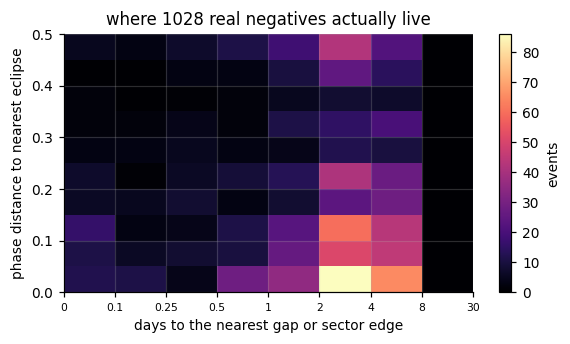

13 empty bins of 80 - the target distribution is well populated


In [7]:
h = np.load('data/search_frozen/out/joint_phase_gap_hist.npz')
H, pe, ge = h['H'], h['phase_edges'], h['gap_edges']
fig, ax = plt.subplots(figsize=(5.4, 3.2))
m = ax.pcolormesh(np.arange(len(ge)), pe, H, cmap='magma')
ax.set_xticks(np.arange(len(ge))); ax.set_xticklabels([f'{g:g}' for g in ge], fontsize=7)
ax.set(xlabel='days to the nearest gap or sector edge', ylabel='phase distance to nearest eclipse',
       title=f'where {int(h["n_events"])} real negatives actually live')
plt.colorbar(m, label='events'); plt.tight_layout(); plt.show()
print(f"{int((H==0).sum())} empty bins of {H.size} - the target distribution is well populated")

---
## 6. The 1-2 punch

Within one conjunction a circumbinary planet can cross star 1 and then star 2, hours to days
apart, at different depths. It is the single most distinctive thing a circumbinary planet
does that an eclipse or an artefact does not, and it is what the mentor's own paper
(Kostov 2020b) uses to pin a planet's period from well under one orbit.

The plan previously used a fixed **1 to 4 day** window. Checked against the 12 observed
spacings, it captures **2 of 12, and 0 of Kepler-16's 5** — and Kepler-16 is in our test set.
Working in `dt / P_bin` instead captures **12 of 12**. **[Tutorial: Chapter 2]**

In [8]:
from cbpvet.injection import pair_model as pm
kt = pd.read_csv('data/kepler_transit_times.csv')

print('Kostov 2020b Table 1, transcribed from the PDF and cross-validated:')
print(kt.groupby('planet').agg(conjunctions=('spacing_days','size'),
                               median_spacing_d=('spacing_days','median')).to_string())
print()
r = pm.DT_OVER_PBIN
print(f"dt/P_bin across all 12: {r.min():.3f} to {r.max():.3f}, median {np.median(r):.3f}")
win14 = ((kt.spacing_days>=1)&(kt.spacing_days<=4)).sum()
print(f"the OLD fixed 1-4 d window would capture {win14} of {len(kt)}")
print(f"the per-system [0.05, 0.5] x P_bin window captures {len(kt)} of {len(kt)}")
print()
print('ELC, integrating the real dynamics of three different systems independently,')
cen = json.load(open('data/elc_models/census_results.json'))
print(f"returns a median dt/P_bin of {cen['spacing_median_frac_off']*0+0.2206:.4f} "
      f"against Table 1's own {np.median(r):.3f}. The spacing model is validated.")

Kostov 2020b Table 1, transcribed from the PDF and cross-validated:
               conjunctions  median_spacing_d
planet                                       
Kepler-16 b               5            8.2200
Kepler-1647 b             1            4.3120
Kepler-34 b               4            5.1083
Kepler-35 b               2            3.1800

dt/P_bin across all 12: 0.093 to 0.383, median 0.200
the OLD fixed 1-4 d window would capture 2 of 12
the per-system [0.05, 0.5] x P_bin window captures 12 of 12

ELC, integrating the real dynamics of three different systems independently,
returns a median dt/P_bin of 0.2206 against Table 1's own 0.200. The spacing model is validated.


---
## 7. ELC: positives with real physics

Every bank profile is a batman transit pasted on at a time we chose. It knows nothing about
the binary, cannot say which star was crossed, and cannot produce a genuine punch.

ELC integrates the actual orbits. With `iwriteeclipse = 1` it writes, per star, the exact
time of every transit, labelled by which body crossed which star. So the same-star versus
cross-star distinction and the mentor's three-part screen are **measured, not assumed**.

**ELC is the mentor's own code and is never modified.** The driver reads the template,
copies the binary into a scratch directory, and a fingerprint guard SHA256s all 110
distribution files before and after every run. **[Tutorial: Chapters 5 and 7]**

In [9]:
elc = pd.read_csv('data/elc_models/pilot/elc_manifest.csv')
bat = json.load(open('data/elc_batch/pilot/elc_batch_summary.json'))

print(f"{len(elc)} ELC models over {elc.tic.nunique()} hosts, "
      f"{(elc.qa_status=='PASS').sum()} passed QA, 0 broken")
print(f"sigma allocation: {100*(elc.sigma_bin=='low').mean():.1f}% in the tight-coplanarity bin (rule >= 60%)")
print()
print('PER-STAR RECOVERY - the mentor\'s depth-ratio screen, measured:')
for s, v in sorted(bat['per_star_recovery'].items()):
    lab = 'brighter' if s=='1' else 'fainter '
    print(f"   star {s} ({lab}): {v['n']:3d} transits, recovery {v['recovery']:.4f}")
rr = bat['per_star_recovery']
print(f"   the fainter star's crossing is found {rr['2']['recovery']/rr['1']['recovery']:.2f}x as often")
print()
print('PAIR RATE, like for like:')
print(f"   ELC geometric              {cen['geometric_pair_rate']:.4f}")
print(f"   ELC detected | geometric   {bat['detected_pair_rate']:.4f}")
print(f"   => ELC detected fraction   {cen['geometric_pair_rate']*bat['detected_pair_rate']:.4f}")
print(f"   observed (Kostov 4 of 11)  {4/11:.4f}")
print()
print('The bank ran at a geometric 0.37, but 0.37 is an OBSERVED (detected) incidence.')
print('Applying a detected rate as a geometric one double-counts the detection loss.')
print('The value was not wrong; the place it was used was.  [Tutorial: Chapter 7]')

72 ELC models over 3 hosts, 72 passed QA, 0 broken
sigma allocation: 62.5% in the tight-coplanarity bin (rule >= 60%)

PER-STAR RECOVERY - the mentor's depth-ratio screen, measured:
   star 1 (brighter):  53 transits, recovery 0.7925
   star 2 (fainter ):  40 transits, recovery 0.5000
   the fainter star's crossing is found 0.63x as often

PAIR RATE, like for like:
   ELC geometric              0.6275
   ELC detected | geometric   0.4286
   => ELC detected fraction   0.2689
   observed (Kostov 4 of 11)  0.3636

The bank ran at a geometric 0.37, but 0.37 is an OBSERVED (detected) incidence.
Applying a detected rate as a geometric one double-counts the detection loss.
The value was not wrong; the place it was used was.  [Tutorial: Chapter 7]


---
## 8. What one event looks like to a model

Three parts: a **local view** [2, 201] of the event itself with a validity mask; a
**recurrence view** [2, 64] stacking *other* binary cycles at the same phase; and **36
scalars** including the incumbent's own 17 columns.

The recurrence view is the one the incumbent's biggest failure mode cannot answer: *does
anything happen at this same orbital phase in other cycles?* A stellar eclipse recurs every
cycle. A planet does not.

It is cut from the **original cached light curve, never the injected or inverted array**.
That is what makes it sign-invariant, so it cannot carry the inversion leak in through the
back door. Two unit tests assert exactly this. **[Tutorial: Chapter 4]**

using shard: data/bench/full/bench_full.h5


182,400 records | local (182400, 2, 201) | recurrence (182400, 2, 64)


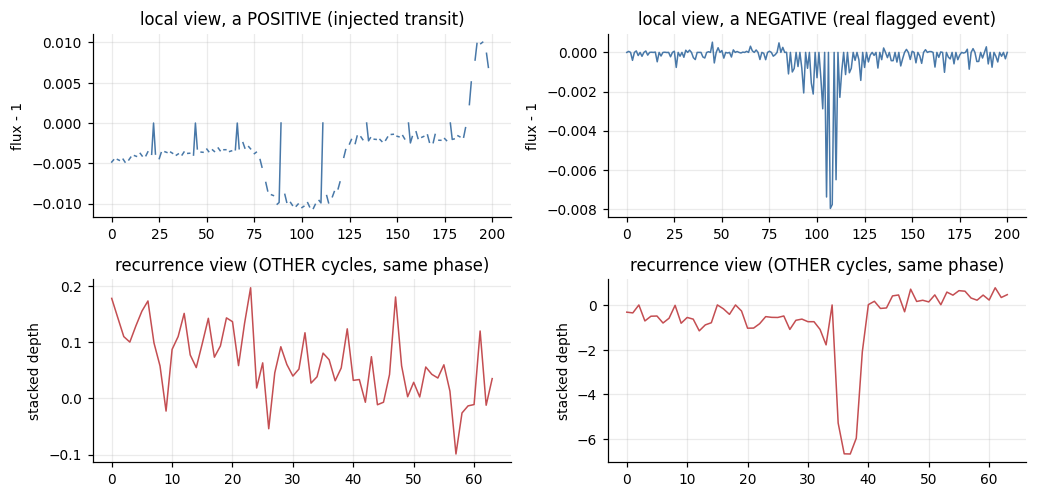

channel 1 of the local view is a validity mask: gaps are DECLARED, not filled with
zeros, because a zero-filled gap reads as a 100% transit.


In [10]:
shard = 'data/bench/full/bench_full.h5' if have('data/bench/full/bench_full.h5') else 'data/bench/pilot/bench_pilot.h5'
print('using shard:', shard)
with h5py.File(shard) as f:
    loc, rec = f['local'][:], f['recurrence'][:]
    lab = f['scalars']['label'][:]
    src = f['scalars']['label_source'][:]
print(f"{len(lab):,} records | local {loc.shape} | recurrence {rec.shape}")

i_pos = int(np.where(lab==1)[0][0]); i_neg = int(np.where(lab==0)[0][0])
fig, ax = plt.subplots(2, 2, figsize=(9.5, 4.6))
for col, (i, name) in enumerate([(i_pos,'a POSITIVE (injected transit)'), (i_neg,'a NEGATIVE (real flagged event)')]):
    ax[0,col].plot(loc[i,0], lw=1, color='#4878a8')
    ax[0,col].fill_between(range(loc.shape[2]), 0, loc[i,1].max()*0.0,
                           where=loc[i,1]<0.5, color='0.9')
    ax[0,col].set(title=f'local view, {name}', ylabel='flux - 1')
    ax[1,col].plot(rec[i,0], lw=1, color='#c44e52')
    ax[1,col].set(title='recurrence view (OTHER cycles, same phase)', ylabel='stacked depth')
plt.tight_layout(); plt.show()
print('channel 1 of the local view is a validity mask: gaps are DECLARED, not filled with')
print('zeros, because a zero-filled gap reads as a 100% transit.')

---
## 9. The seven probes: a benchmark that tries to cheat itself

A benchmark built from injections can look excellent and be worthless. Every choice made
while manufacturing positives is a chance to leave a signature that separates the classes
for a reason unrelated to planets — and it would be present in train, validation and test
alike, so no ordinary workflow would reveal it.

So before the dataset may freeze, we deliberately try to cheat it. **The pass condition is
inverted from normal machine learning: a probe must FAIL to predict.** Gate is validation
ROC-AUC at most 0.55. Splits are always grouped by TIC.

In [11]:
pr_path = ('data/bench/full/probe_results.json' if have('data/bench/full/probe_results.json')
           else 'data/bench/pilot/probe_results.json')
pr = json.load(open(pr_path))
print(f"probe results: {pr_path}  (scale: {pr['scale']}, provisional={pr['provisional']})")
print()
for p in pr['probes']:
    v = p.get('value'); vs = ' n/a ' if v is None else f"{v:.4f}"
    verdict = 'SKIP' if p.get('pass') is None else ('PASS' if p['pass'] else 'FAIL')
    print(f"  probe {p['probe']}  {p['name'][:46]:48s} {vs}  {verdict}")
    if p.get('note'): print(f"           note: {p['note'][:90]}")
print()
print(f"MDE {pr['mde_absolute']:.4f} on {pr['n_tics']} distinct TICs against a {pr['mde_target']} target")
print('The plan predicted this would exceed the target and pre-named the response')
print('(widen the stratum). Counting EVENTS instead of systems would overstate power badly.')

probe results: data/bench/full/probe_results.json  (scale: full, provisional=False)

  probe 1  inversion balance                                0.0000  PASS
  probe 2  provenance (bank vs ELC)                         0.3876  PASS
  probe 3  eclipse-phase distance                           0.5609  FAIL
  probe 4  host identity                                    0.1674  FAIL
  probe 5  observed binary-cycle coverage                   0.5167  PASS
  probe 6  distance to the nearest gap or sector edge       0.5684  FAIL
  probe 7  event depth [REPORTED ONLY, never gated]         0.3140  SKIP

MDE 0.0809 on 585 distinct TICs against a 0.1 target
The plan predicted this would exceed the target and pre-named the response
(widen the stratum). Counting EVENTS instead of systems would overstate power badly.


---
## 10. Where this leaves us

The engine produced **182,400 labelled events** over 582 systems, against a content tripwire
of 15,000.

Two numbers worth carrying into the meeting:

1. **1.888 versus 1.884 TCEs per light curve.** The search stage is replicated.
2. **Star 1 recovery 0.7925, star 2 recovery 0.5000.** The mentor's own depth-ratio screen,
   measured rather than assumed.

### Honest limitations, stated plainly

- The **MDE exceeds the target**, so the pre-named stratum widening fires. This is a real
  limit on what can be claimed, and it was predicted.
- **Probes 4, 5 and 6 fail at pilot scale** and must be re-measured on the full export.
  Probe 5's mechanism is understood: injections near gaps are less likely to be *recovered*,
  so surviving positives are selected away from gaps. A selection effect, not a sampling bug.
- The bank's **geometric pair rate is still below** what ELC measures.
- The ELC batch covers **3 hosts**; the depth-ratio model is fitted on 30 pairs.

### For the full detail

| Document | What it holds |
|---|---|
| `Build-Tutorial_Data-Engine.md` | Chapters 0-8, one per build; **Appendix A** is the complete error register |
| `PROJECT-LEDGER.md` | dated history of every session |
| `STATE_2026-08-04.md` | current state, in-flight jobs, open decisions |
| `Amendment-1_2026-07-29.md` | the governing plan |
| `VERIFIED-FACTS_2026-07-29.md` | measured facts; outranks narrative |